In [76]:
# lidar crest data audit

# Visual sense check of station spacing - ive chosen 5 m as a sensible value without any sensitivity test or tuning yet
# ive chose transect width to be 25 m
# crest search band is plus or minus 10 


In [77]:

from math import hypot

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import polars as pl
import rasterio
from scipy.signal import savgol_filter
from shapely.ops import linemerge

from project_paths import paths
from src.features import prepare_features

WINDOWS = paths.data / "lidar" / "dtm_windows"

SPACING = 5.0        # along the line of the asset, sampling spacing in metres
HALF_W = 25.0        # transect half width
CREST_BAND = 10.0    # crest search band around the line - plus or minus
SMOOTH_M = 3         # cross section smoothing window
TOE_SLOPE = 0.05     # gradient below which the descent is treated as toe


In [78]:

OFFSETS = np.arange(-HALF_W, HALF_W + 1.0, 1.0)  # perpendicular sample offsets


In [79]:


TIERS = {
    "engineered_raised": ["Embankment", "Engineered High Ground", "Barrier Beach"],
    "natural_geomorphic": ["Cliff", "Dunes", "Beach"],
    "wall_like": ["Wall", "Quay", "Promenade", "Demountable Defence"],
    "point": ["Flood Gate", "Weir", "Spillway", "Bridge Abutment"],
}
SUBTYPE_TIER = {s: t for t, subs in TIERS.items() for s in subs}


In [80]:


scope = prepare_features(pl.read_parquet(paths.unified_file))["asset_id"].to_list()
assets = gpd.read_file(paths.aims_data / "aims.gpkg", columns=["asset_id", "asset_sub_type"])
assets["asset_id"] = assets["asset_id"].astype("int64")
assets = assets[assets["asset_id"].isin(scope)].reset_index(drop=True)


In [81]:

assert assets.crs.to_epsg() == 27700


In [82]:

on_disk = {int(p.stem) for p in WINDOWS.glob("*.tif")}
assets = assets[assets["asset_id"].isin(on_disk)].reset_index(drop=True)
assets["tier"] = assets["asset_sub_type"].map(SUBTYPE_TIER)


In [83]:
len(assets)

4035

In [84]:
assets.groupby("tier").size()

tier
engineered_raised     3091
natural_geomorphic      29
point                   37
wall_like              878
dtype: int64

In [85]:

rng = np.random.default_rng(42)
sample = {
    tier: assets[assets["tier"] == tier].sample(
        min(400, (assets["tier"] == tier).sum()),
        random_state=123
    )["asset_id"].tolist()
    for tier in ("engineered_raised", "wall_like", "natural_geomorphic")
}


In [86]:

sample


{'engineered_raised': [123442,
  124596,
  142582,
  142299,
  119970,
  131717,
  110237,
  143779,
  121791,
  135977,
  105403,
  116779,
  103638,
  143153,
  103635,
  125967,
  12370,
  132407,
  112157,
  116106,
  139655,
  133582,
  115360,
  130136,
  147064,
  116545,
  142670,
  142588,
  122591,
  122592,
  105376,
  113124,
  123610,
  142444,
  132633,
  116903,
  124921,
  105762,
  122593,
  124156,
  114066,
  106265,
  108106,
  120856,
  146061,
  143110,
  135014,
  104413,
  127223,
  119677,
  106078,
  131324,
  145040,
  137238,
  130913,
  124002,
  133523,
  102743,
  119007,
  135078,
  142580,
  120974,
  123387,
  118413,
  131448,
  105454,
  115902,
  119676,
  114419,
  123677,
  122756,
  133235,
  116982,
  1368,
  136945,
  132086,
  120812,
  135667,
  125198,
  105398,
  114967,
  107159,
  117090,
  117434,
  118554,
  107419,
  119679,
  128863,
  104569,
  122950,
  145278,
  115199,
  123443,
  130960,
  131601,
  125809,
  129135,
  124183,
  

In [87]:


def longest_line(geom):
    if geom.geom_type == "LineString":
        return geom
    merged = linemerge(geom)
    if merged.geom_type == "LineString":
        return merged
    return max(merged.geoms, key=lambda g: g.length)


In [88]:
from functools import partial

def stations(line):
    d = np.arange(0.0, line.length, SPACING)
    L = line.length
    pts, perps = [], []
    for di in d:
        a = line.interpolate(max(0.0, di - SPACING / 2))
        b = line.interpolate(min(L, di + SPACING / 2))
        tx, ty = b.x - a.x, b.y - a.y
        n = hypot(tx, ty) or 1.0
        perps.append((-ty / n, tx / n))          
        p = line.interpolate(di)
        pts.append((p.x, p.y))
    return d, np.array(pts), np.array(perps)


def sample_sections(src, pts, perps):
    coords = (pts[:, None, :] + OFFSETS[None, :, None] * perps[:, None, :]).reshape(-1, 2)
    vals = np.array([v[0] for v in src.sample(coords)], dtype="float64")
    if src.nodata is not None:
        vals[vals == src.nodata] = np.nan
    return vals.reshape(len(pts), len(OFFSETS))    


TOE_RISE_EPS = 0.02   # toe is first local min out from crest - stop only when the profile rises

def walk(ci, sm, finite, step):
    i = ci
    while 0 < i + step < len(sm):
        nxt = i + step
        if not finite[nxt]:
            break
        if sm[nxt] > sm[i] + TOE_RISE_EPS:   
            break
        i = nxt
    return i

def crest_and_toes(row):
    band = np.abs(OFFSETS) <= CREST_BAND
    finite = np.isfinite(row)
    fill = np.nanmin(row) if finite.any() else 0.0
    sm = np.convolve(np.nan_to_num(row, nan=fill), np.ones(SMOOTH_M) / SMOOTH_M, mode="same")
    ci = int(np.argmax(np.where(band, sm, -np.inf)))

    toe_walk = partial(walk, ci, sm, finite)

    li, ri = toe_walk(step=-1), toe_walk(step=+1)
    return dict(
        crest_off=float(OFFSETS[ci]), crest_z=float(row[ci]), crest_idx=ci,
        toe_l=float(row[li]), toe_r=float(row[ri]), li=li, ri=ri,
        relheight=float(row[ci] - np.nanmean([row[li], row[ri]])),
        width=float(OFFSETS[ri] - OFFSETS[li]),   
    )


In [89]:

def extract(asset_id, geom):
    line = longest_line(geom)
    d, pts, perps = stations(line)
    with rasterio.open(WINDOWS / f"{asset_id}.tif") as src:
        sections = sample_sections(src, pts, perps)
    recs = [crest_and_toes(sections[i]) | {"chainage": float(d[i])} for i in range(len(d))]
    df = pl.DataFrame(recs)
    crest_xy = pts + df["crest_off"].to_numpy()[:, None] * perps
    return df, sections, pts, crest_xy


def resid_features(chainage, crest_z):
    ok = np.isfinite(crest_z)
    if ok.sum() < 5:
        return None
    z = crest_z[ok]
    win = min(len(z) - (len(z) + 1) % 2, 11)      # odd, <= n
    win = max(win, 5)
    trend = savgol_filter(z, window_length=win, polyorder=2)
    r = z - trend
    rng = r.max() - r.min()
    return dict(
        resid_std=float(r.std()),
        ac1=float(np.corrcoef(r[:-1], r[1:])[0, 1]) if len(r) > 2 else np.nan,
        tv_range=float(np.abs(np.diff(r)).sum() / rng) if rng > 0 else np.nan,
        n_valid=int(ok.sum()), frac_valid=float(ok.mean()),
        crest_offset_median=float(np.nanmedian(np.abs(np.array(chainage) * 0))),  # placeholder, see below
        trend=trend, resid=r, ok=ok,
    )


def plan_view(asset_id, geom):
    df, sections, pts, crest_xy = extract(asset_id, geom)
    line = longest_line(geom)
    xs, ys = line.xy
    with rasterio.open(WINDOWS / f"{asset_id}.tif") as src:
        dem = src.read(1, masked=True)
        extent = (src.bounds.left, src.bounds.right, src.bounds.bottom, src.bounds.top)
    fig, ax = plt.subplots(figsize=(7, 7))
    im = ax.imshow(dem, extent=extent, origin="upper", cmap="terrain")
    ax.plot(xs, ys, "k--", lw=1, label="AIMS line (anchor)")
    ax.scatter(crest_xy[:, 0], crest_xy[:, 1], s=10, c="red", label="recovered crest")
    ax.set_title(f"{asset_id}  ({SUBTYPE_TIER.get(assets.set_index('asset_id').loc[asset_id,'asset_sub_type'])})")
    ax.legend(loc="upper right"); fig.colorbar(im, ax=ax, shrink=0.7, label="elev (m)")
    plt.show()
    return df, sections


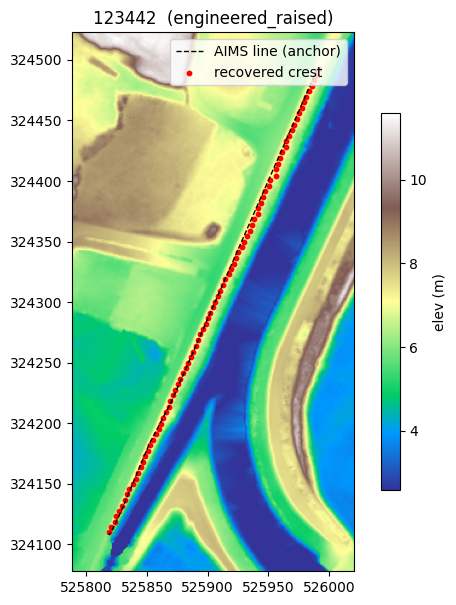

crest_off,crest_z,crest_idx,toe_l,toe_r,li,ri,relheight,width,chainage
f64,f64,i64,f64,f64,i64,i64,f64,f64,f64
1.0,7.114,26,5.618,2.741891,12,50,2.934054,38.0,0.0
2.0,7.121,27,5.587,2.667654,13,50,2.993673,37.0,5.0
1.0,7.206,26,5.604,2.663731,13,50,3.072134,37.0,10.0
2.0,7.093,27,5.643,2.670337,13,50,2.936331,37.0,15.0
1.0,7.115,26,5.69,2.705597,13,50,2.917201,37.0,20.0
…,…,…,…,…,…,…,…,…,…
-2.0,6.976,23,4.834,2.58,1,41,3.269,40.0,400.0
-2.0,6.983,23,4.821,2.58,1,40,3.2825,39.0,405.0
-1.0,6.781,24,4.849,2.58,1,41,3.0665,40.0,410.0


In [90]:

aid = sample["engineered_raised"][0]
geom = assets.set_index("asset_id").loc[aid, "geometry"]
df, sections = plan_view(aid, geom)

df

In [91]:
sections

array([[6.10900021, 6.09800005, 6.11100006, ..., 2.77699995, 2.77699995,
        2.74189115],
       [6.08900023, 6.079     , 6.09399986, ..., 2.67600012, 2.67651916,
        2.66765404],
       [6.11399984, 6.11600018, 6.11899996, ..., 2.67848897, 2.67848897,
        2.66373086],
       ...,
       [4.83099985, 4.84899998, 4.86800003, ..., 5.58300018, 6.09899998,
        6.84499979],
       [4.81099987, 4.84899998, 4.87099981, ..., 6.03399992, 6.68200016,
        6.91900015],
       [4.82399988, 4.84600019, 4.88800001, ..., 5.75199986, 5.79799986,
        5.85500002]], shape=(85, 51))

In [92]:

# def cross_sections(df, sections, n=4):
#     idx = np.linspace(0, len(df) - 1, n).astype(int)
#     fig, axes = plt.subplots(1, n, figsize=(4 * n, 3), sharey=True)

#     for ax, i in zip(axes, idx):
#         r = crest_and_toes(sections[i])
#         ax.plot(OFFSETS, sections[i], lw=1)
#         ax.axvspan(-CREST_BAND, CREST_BAND, color="grey", alpha=0.1)

#         ax.scatter(r["crest_off"], r["crest_z"], c="red", zorder=5, label="crest")
#         ax.scatter(
#             [OFFSETS[r["li"]], OFFSETS[r["ri"]]], 
#             [r["toe_l"], r["toe_r"]],
#             c="green", 
#             zorder=5, 
#             label="toe"
#         )

#         ax.set_title(f"chainage {df['chainage'][i]:.0f} m")
#         ax.set_xlabel("offset (m)")

#     axes[0].set_ylabel("elev (m)")
#     axes[0].legend(fontsize=8)

#     plt.tight_layout()
#     plt.show()

def cross_sections(df, sections, n=4):
    idx = np.linspace(0, len(df) - 1, n).astype(int)
    chain = df["chainage"].to_list()   
    fig, axes = plt.subplots(1, n, figsize=(4 * n, 3), sharey=True)

    for ax, i in zip(axes, idx):
        i = int(i)

        r = crest_and_toes(sections[i])
        ax.plot(OFFSETS, sections[i], lw=1)
        ax.axvspan(-CREST_BAND, CREST_BAND, color="grey", alpha=0.1)

        ax.scatter(r["crest_off"], r["crest_z"], c="red", zorder=5, label="crest")
        ax.scatter(
            [OFFSETS[r["li"]], OFFSETS[r["ri"]]], 
            [r["toe_l"], r["toe_r"]],
            c="green", 
            zorder=5, 
        label="toe"
        )
        
        ax.set_title(f"chainage {chain[i]:.0f} m")
        ax.set_xlabel("offset (m)")

    axes[0].set_ylabel("elev (m)")
    axes[0].legend(fontsize=8)

    plt.tight_layout()
    plt.show()


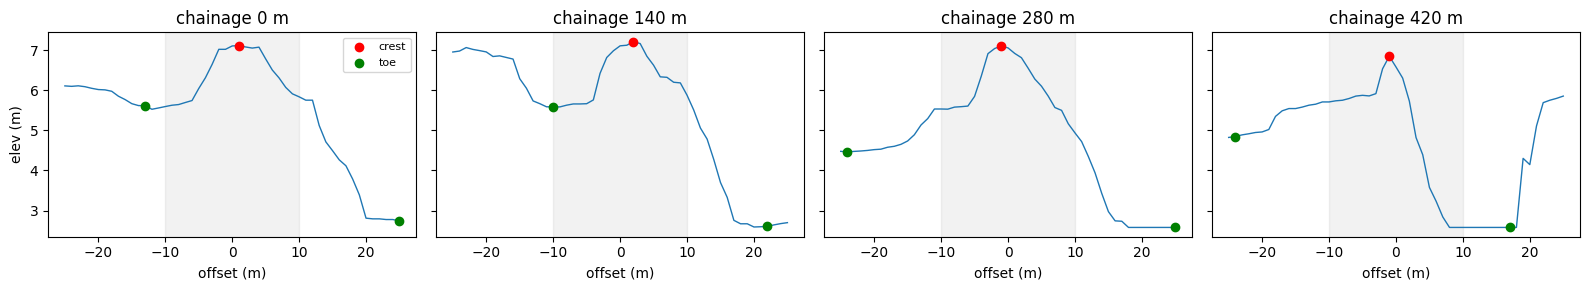

In [93]:

cross_sections(df, sections)


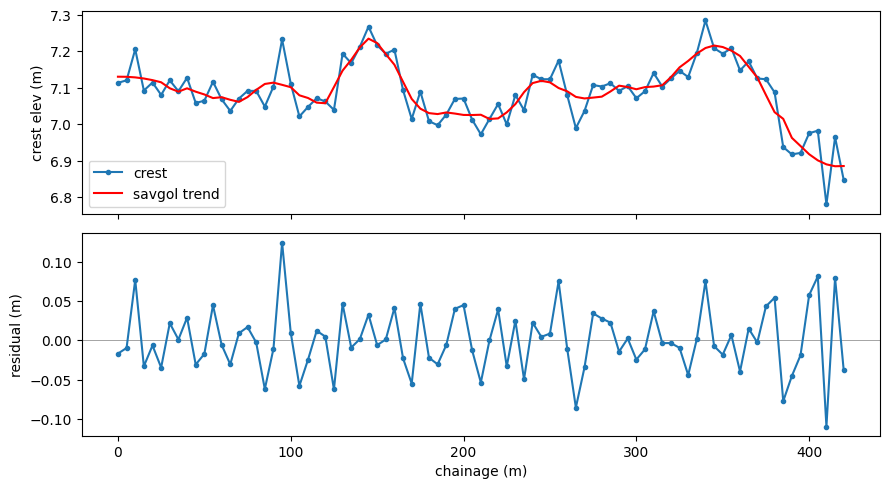

{'resid_std': 0.04, 'ac1': -0.177, 'tv_range': 17.656, 'n_valid': 85, 'frac_valid': 1.0}


In [94]:


def longitudinal(df):
    ch = df["chainage"].to_numpy(); z = df["crest_z"].to_numpy()
    f = resid_features(ch, z)
    if f is None:
        print("too few valid stations"); return
    fig, (a1, a2) = plt.subplots(2, 1, figsize=(9, 5), sharex=True)
    chv = ch[f["ok"]]
    a1.plot(chv, z[f["ok"]], ".-", label="crest"); a1.plot(chv, f["trend"], "r-", label="savgol trend")
    a1.set_ylabel("crest elev (m)"); a1.legend()
    a2.axhline(0, color="grey", lw=0.5); a2.plot(chv, f["resid"], ".-")
    a2.set_ylabel("residual (m)"); a2.set_xlabel("chainage (m)")
    plt.tight_layout(); plt.show()
    print(
        {
            k: round(v, 3) for k, v in f.items()
            if k in ("resid_std", "ac1", "tv_range", "n_valid", "frac_valid")
        }
    )

longitudinal(df)


In [95]:


rows = []
by_id = assets.set_index("asset_id")

for tier, ids in sample.items():

    for aid in ids:

        df_a, *_ = extract(aid, by_id.loc[aid, "geometry"])
        f = resid_features(df_a["chainage"].to_numpy(), df_a["crest_z"].to_numpy())
        rows.append({
            "asset_id": aid, "tier": tier,
            "sub_type": by_id.loc[aid, "asset_sub_type"],
            "offset_median": float(df_a["crest_off"].abs().median()),
            "relheight_med": float(df_a["relheight"].median()),
            **(
                {k: round(f[k], 3) for k in ("resid_std", "ac1", "tv_range", "frac_valid")}
                if f else {}
            ),
        })
        
pl.DataFrame(rows)

asset_id,tier,sub_type,offset_median,relheight_med,resid_std,ac1,tv_range,frac_valid
i64,str,str,f64,f64,f64,f64,f64,f64
123442,"""engineered_raised""","""Embankment""",1.0,3.044,0.04,-0.177,17.656,1.0
124596,"""engineered_raised""","""Embankment""",1.0,3.19375,0.027,-0.068,14.873,1.0
142582,"""engineered_raised""","""Embankment""",8.0,0.3615,0.036,-0.735,3.753,1.0
142299,"""engineered_raised""","""Embankment""",2.0,1.96175,0.038,0.16,19.516,1.0
119970,"""engineered_raised""","""Engineered High Ground""",7.0,2.145,0.155,-0.219,9.744,1.0
…,…,…,…,…,…,…,…,…
145597,"""natural_geomorphic""","""Beach""",4.0,1.0405,0.144,-0.076,12.177,1.0
129501,"""natural_geomorphic""","""Beach""",10.0,0.991,0.198,-0.03,17.528,1.0
147046,"""natural_geomorphic""","""Beach""",8.5,0.64275,0.167,0.228,17.526,1.0


In [96]:
with pl.Config(tbl_rows=-1, tbl_cols=-1, tbl_width_chars=220):
    print(pl.DataFrame(rows))

shape: (829, 9)
┌──────────┬────────────────────┬────────────────────────┬───────────────┬───────────────┬───────────┬────────┬──────────┬────────────┐
│ asset_id ┆ tier               ┆ sub_type               ┆ offset_median ┆ relheight_med ┆ resid_std ┆ ac1    ┆ tv_range ┆ frac_valid │
│ ---      ┆ ---                ┆ ---                    ┆ ---           ┆ ---           ┆ ---       ┆ ---    ┆ ---      ┆ ---        │
│ i64      ┆ str                ┆ str                    ┆ f64           ┆ f64           ┆ f64       ┆ f64    ┆ f64      ┆ f64        │
╞══════════╪════════════════════╪════════════════════════╪═══════════════╪═══════════════╪═══════════╪════════╪══════════╪════════════╡
│ 123442   ┆ engineered_raised  ┆ Embankment             ┆ 1.0           ┆ 3.044         ┆ 0.04      ┆ -0.177 ┆ 17.656   ┆ 1.0        │
│ 124596   ┆ engineered_raised  ┆ Embankment             ┆ 1.0           ┆ 3.19375       ┆ 0.027     ┆ -0.068 ┆ 14.873   ┆ 1.0        │
│ 142582   ┆ engineered_raised  

In [97]:
summary = pl.DataFrame(rows).group_by("tier", "sub_type").agg(
    pl.len().alias("n"),
    (pl.col("offset_median") >= 9).mean().round(2).alias("frac_pinned"),
    ((pl.col("offset_median") >= 9) & (pl.col("relheight_med") < 0.5)).mean().round(2).alias("frac_failed"),
    (pl.col("resid_std") < 0.05).mean().round(2).alias("frac_below_floor"),
    (pl.col("relheight_med") <= 0.1).mean().round(2).alias("frac_flat"),
).sort("tier", "sub_type")

summary

tier,sub_type,n,frac_pinned,frac_failed,frac_below_floor,frac_flat
str,str,u32,f64,f64,f64,f64
"""engineered_raised""","""Embankment""",303,0.06,0.0,0.54,0.0
"""engineered_raised""","""Engineered High Ground""",97,0.67,0.02,0.15,0.01
"""natural_geomorphic""","""Beach""",23,0.57,0.04,0.17,0.0
"""natural_geomorphic""","""Dunes""",6,0.0,0.0,0.0,0.0
"""wall_like""","""Wall""",400,0.34,0.05,0.21,0.01
